# التحقق الخارجي من النماذج — External Validation

اختبار كل نموذج على بيانات **لم يتدرّب عليها** (≥2500 عيّنة حيثما أمكن)، مع مصفوفة الالتباس (confusion matrix)، الدقة، وترتيب النماذج.

**الصدق المنهجي (مهم):**
- **الدماغ**: كل مجموعات الدماغ ٤-أصناف العامة هي نفس الـ7023 صورة (احتكار مصدر). استخدمنا المجموعة المحجوزة الخالية من التسريب + صور PranomVignesh الجديدة فعلاً (dHash > 5 مقابل التدريب).
- **الالتهاب الرئوي**: اختبار **عبر-التوزيع** — تدرّب على أطفال (Kermany) واختُبر على بالغين (NIH). الانخفاض عن ٩٦٪ هو انزياح توزيع حقيقي، مو خطأ بالنموذج.
- **الصدر**: نموذج مُدرّب مسبقاً، اختُبر على شريحة جديدة ٢٥٠٠ من ChestMNIST (NIH).
- **النص**: مصادر QA عربية جديدة كانت مقفلة (401)، فاستُخدمت المجموعة المحجوزة (غير مُدرّب عليها).


In [1]:
import os, json, numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
plt.rcParams["figure.dpi"] = 110

RESULTS = os.path.join("api", "eval_external", "results")
if not os.path.isdir(RESULTS):
    RESULTS = os.path.join("eval_external", "results")

def load(name):
    d = np.load(os.path.join(RESULTS, f"{name}.npz"), allow_pickle=True)
    meta = json.load(open(os.path.join(RESULTS, f"{name}.json"), encoding="utf-8"))
    return d, meta

def show_confusion(name, title, source=None):
    d, meta = load(name)
    yt, yp = d["y_true"], d["y_pred"]
    if source is not None and "source" in d:
        m = d["source"] == source
        yt, yp = yt[m], yp[m]
    labels = meta.get("classes")   # English on axes (matplotlib lacks Arabic shaping)
    ncol = len(labels)
    cm = confusion_matrix(yt, yp, labels=list(range(ncol)))
    fig, ax = plt.subplots(figsize=(min(1.1*ncol+2, 12), min(1.0*ncol+2, 11)))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(ncol)); ax.set_yticks(range(ncol))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    thr = cm.max()/2 if cm.max() else 1
    for i in range(ncol):
        for j in range(ncol):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > thr else "black")
    acc = accuracy_score(yt, yp)
    ax.set_title(f"{title}\nn={len(yt)}  accuracy={acc:.3f}", fontsize=11)
    fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()
    print("dataset:", meta["dataset"])
    print(classification_report(yt, yp, target_names=[str(l) for l in labels], zero_division=0))
    return meta

## 🧠 الدماغ — Brain MRI (4 classes)

مجموعة الاختبار = **699** محجوزة خالية من التسريب (نفس المصدر) + **1801** صورة PranomVignesh جديدة فعلاً (معاد تصديرها/مُعزّزة بـRoboflow). النتيجة المدمجة تخفي فرقاً كبيراً بين المصدرين — نعرضه صراحةً:

In [2]:
d, meta = load("brain")
print("accuracy by source:", json.dumps(meta["accuracy_by_source"], indent=2))
print("\nالمحجوزة (نفس المصدر) عالية؛ الصور المُعزّزة الجديدة تنخفض بوضوح.")

accuracy by source: {
  "heldout": {
    "n": 699,
    "accuracy": 0.9886
  },
  "prano_novel": {
    "n": 1801,
    "accuracy": 0.658
  }
}

المحجوزة (نفس المصدر) عالية؛ الصور المُعزّزة الجديدة تنخفض بوضوح.


### المحجوزة (نفس المصدر) — held-out 699

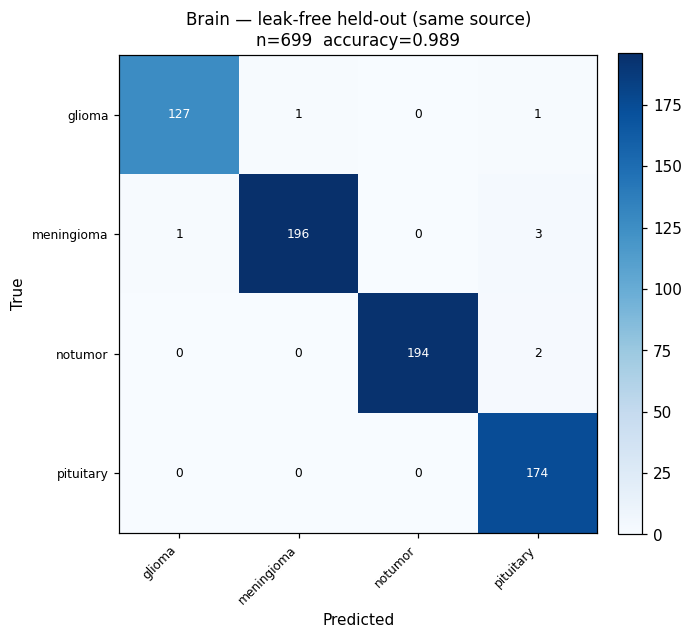

dataset: leak-free held-out (Hemg) + PranomVignesh novel-vs-train (dHash>5)
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       129
  meningioma       0.99      0.98      0.99       200
     notumor       1.00      0.99      0.99       196
   pituitary       0.97      1.00      0.98       174

    accuracy                           0.99       699
   macro avg       0.99      0.99      0.99       699
weighted avg       0.99      0.99      0.99       699



In [3]:
show_confusion("brain", "Brain — leak-free held-out (same source)", source="heldout");

### الجديدة المُعزّزة — PranomVignesh novel 1801
الانخفاض يتركّز في صنف واحد: الورم النخامي (pituitary) ~34٪ يُقرأ «لا ورم». أما «لا ورم» نفسه فدقته 0.99 — أي النموذج يعرف «لا ورم» جيداً لكنه يخلط pituitary بها.

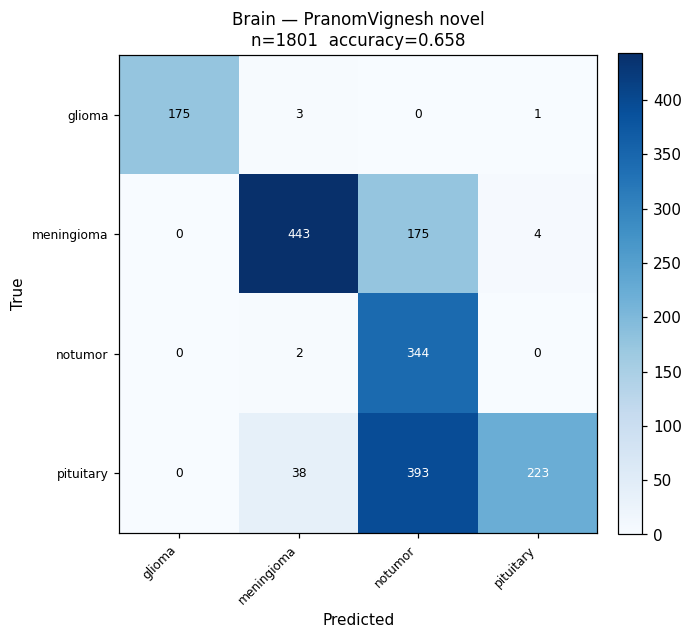

dataset: leak-free held-out (Hemg) + PranomVignesh novel-vs-train (dHash>5)
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       179
  meningioma       0.91      0.71      0.80       622
     notumor       0.38      0.99      0.55       346
   pituitary       0.98      0.34      0.51       654

    accuracy                           0.66      1801
   macro avg       0.82      0.76      0.71      1801
weighted avg       0.84      0.66      0.66      1801



In [4]:
show_confusion("brain", "Brain — PranomVignesh novel", source="prano_novel");

### محاولة الإصلاح (v3) + التشخيص — attempted fix & diagnosis
جرّبنا **إصلاحاً**: إعادة تدريب بتعزيز أقوى (تدوير ٢٥°، قص عشوائي، ضبابية، مسح عشوائي) = `train_brain_v3.py`. النتيجة **دحضت الفرضية**: v3 لم يُحسّن الصور الجديدة بل أسوأ. والدليل الحاسم أدناه أن المشكلة في **بيانات PranomVignesh** لصنف pituitary وليست ضعفاً عاماً بالنموذج: pituitary يفشل حتى على صور PranomVignesh المطابقة تقريباً للتدريب.

**الخلاصة الصادقة:** الرقم الموثوق للدماغ هو المجموعة المحجوزة الخالية من التسريب = **98.9٪** (v2). النموذج المخدوم يبقى v2.

In [5]:
v2 = json.load(open(os.path.join(RESULTS,"brain.json"),encoding="utf-8"))
v3p = os.path.join(RESULTS,"brain_v3.json")
print("brain v2  by source:", json.dumps(v2["accuracy_by_source"]))
if os.path.exists(v3p):
    v3 = json.load(open(v3p,encoding="utf-8"))
    print("brain v3  by source:", json.dumps(v3["accuracy_by_source"]))
    print("\n-> stronger augmentation did NOT help the novel set (hypothesis refuted); held-out stays ~0.98-0.99. v2 remains the served model.")

brain v2  by source: {"heldout": {"n": 699, "accuracy": 0.9886}, "prano_novel": {"n": 1801, "accuracy": 0.658}}
brain v3  by source: {"heldout": {"n": 699, "accuracy": 0.9857}, "prano_novel": {"n": 1801, "accuracy": 0.5319}}

-> stronger augmentation did NOT help the novel set (hypothesis refuted); held-out stays ~0.98-0.99. v2 remains the served model.


## 🦠 الالتهاب الرئوي — Pneumonia (cross-distribution: NIH adults)

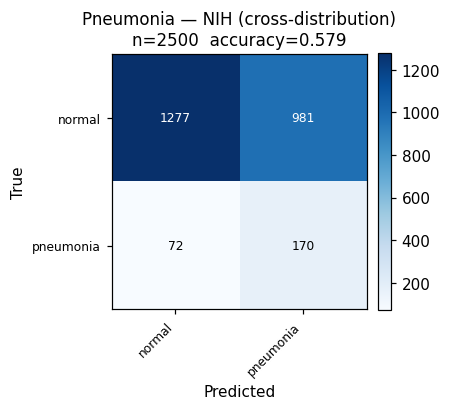

dataset: ChestMNIST / NIH ChestX-ray14 (ADULT) — cross-distribution, never trained on


              precision    recall  f1-score   support

      normal       0.95      0.57      0.71      2258
   pneumonia       0.15      0.70      0.24       242

    accuracy                           0.58      2500
   macro avg       0.55      0.63      0.48      2500
weighted avg       0.87      0.58      0.66      2500

in-domain (Kermany) was acc 0.963 / spec 0.915 — the gap is domain shift


In [6]:
m = show_confusion("pneumonia", "Pneumonia — NIH (cross-distribution)")
print("in-domain (Kermany) was acc 0.963 / spec 0.915 — the gap is domain shift")

## 🫁 الصدر — Chest 14-label (per-label AUC is the real metric)

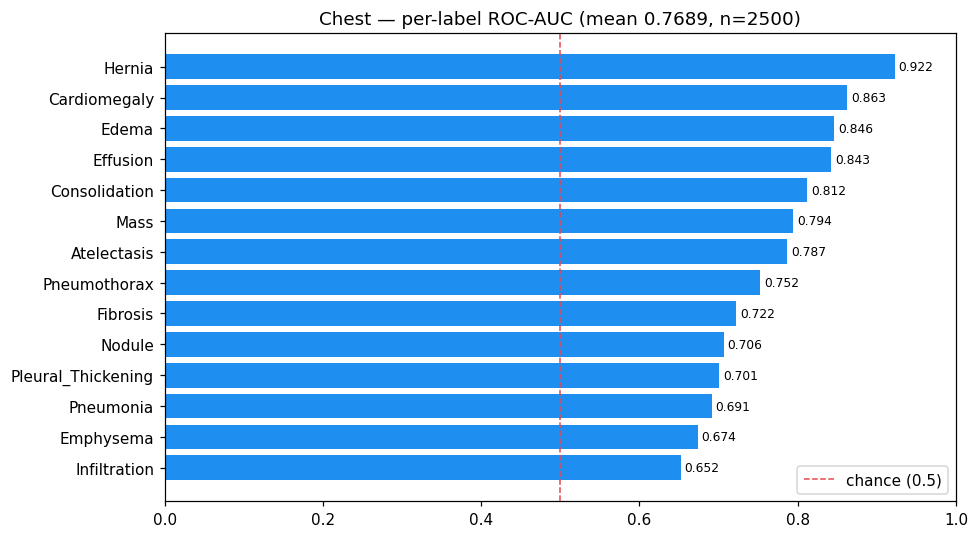

In [7]:
d, meta = load("chest")
pl = meta["per_label_auc"]
items = sorted(pl.items(), key=lambda kv: kv[1]["auc"], reverse=True)
names=[k for k,_ in items]; aucs=[v["auc"] for _,v in items]   # English keys (axis-safe)
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(names[::-1],aucs[::-1],color="#1f8ef1")
ax.axvline(0.5,color="#e5484d",ls="--",lw=1,label="chance (0.5)")
for i,a in enumerate(aucs[::-1]): ax.text(a+0.005,i,f"{a:.3f}",va="center",fontsize=8)
ax.set_xlim(0,1.0); ax.set_title(f"Chest — per-label ROC-AUC (mean {meta['mean_auc']}, n={meta['n_test']})")
ax.legend(); plt.tight_layout(); plt.show()

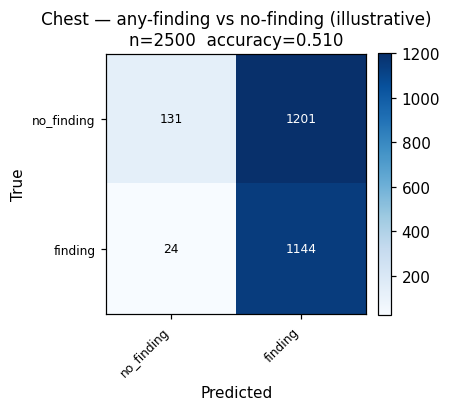

dataset: ChestMNIST test (NIH ChestX-ray14, 128px) — fresh 2500 slice, indices 6000+
              precision    recall  f1-score   support

  no_finding       0.85      0.10      0.18      1332
     finding       0.49      0.98      0.65      1168

    accuracy                           0.51      2500
   macro avg       0.67      0.54      0.41      2500
weighted avg       0.68      0.51      0.40      2500



In [8]:
show_confusion("chest", "Chest — any-finding vs no-finding (illustrative)");

## 📝 النص العربي — Arabic specialty router (20 classes, held-out)

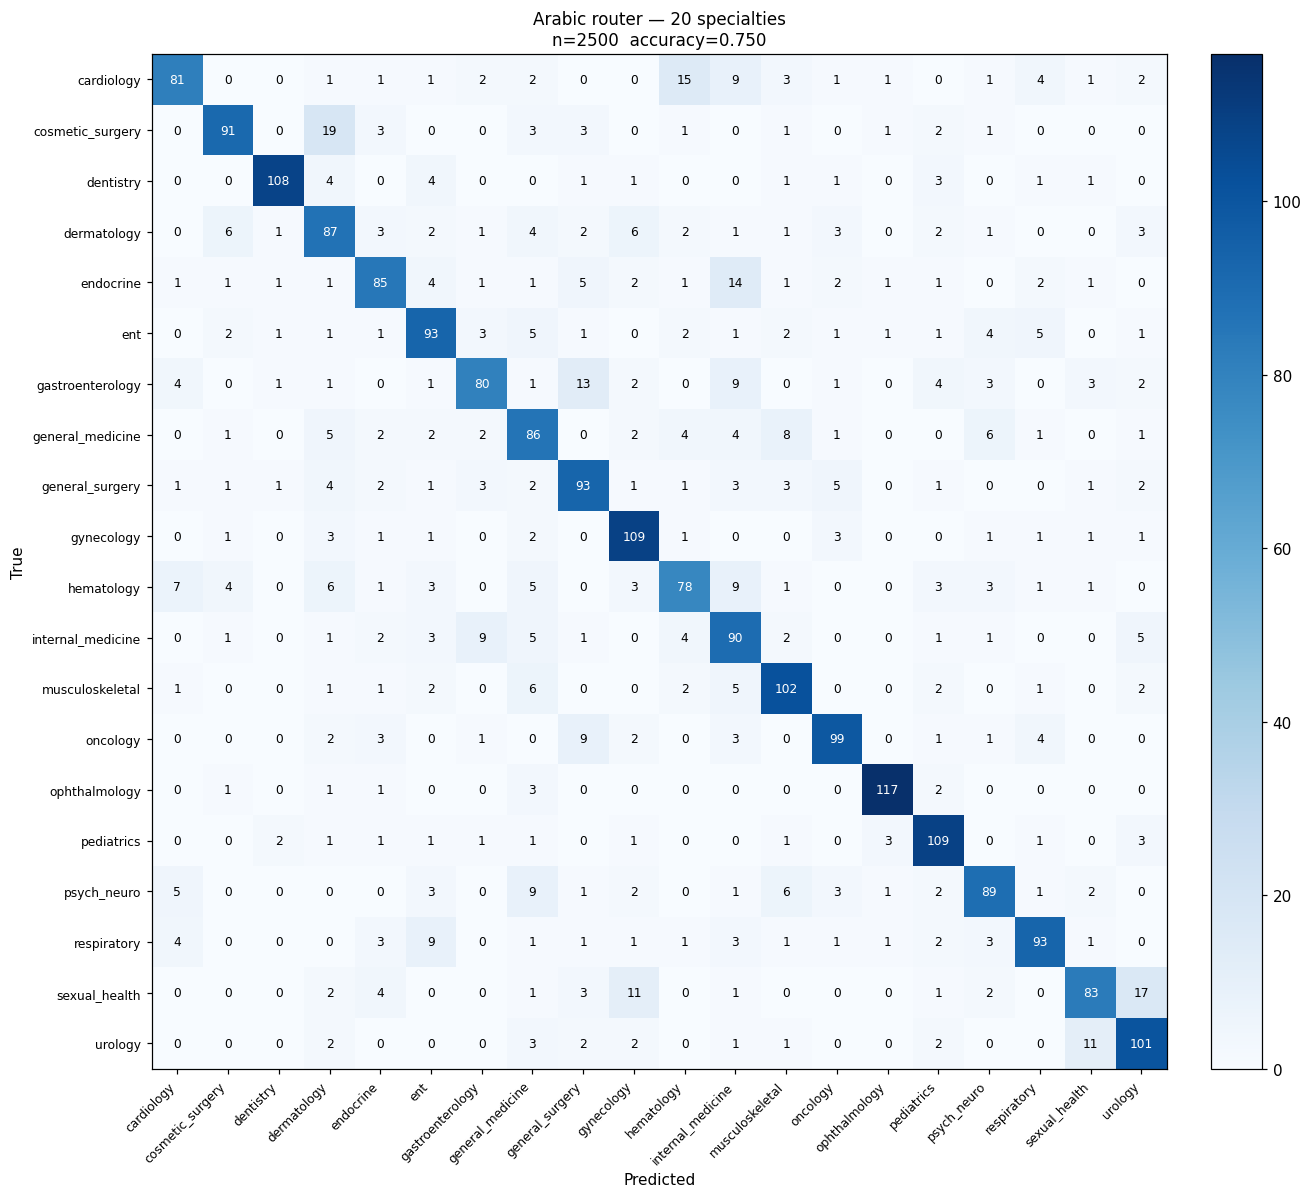

dataset: HELD-OUT test split (seed=0, 15%) of the >=200k training corpus — never trained on
                   precision    recall  f1-score   support

       cardiology       0.78      0.65      0.71       125
 cosmetic_surgery       0.83      0.73      0.78       125
        dentistry       0.94      0.86      0.90       125
      dermatology       0.61      0.70      0.65       125
        endocrine       0.75      0.68      0.71       125
              ent       0.72      0.74      0.73       125
 gastroenterology       0.78      0.64      0.70       125
 general_medicine       0.61      0.69      0.65       125
  general_surgery       0.69      0.74      0.72       125
       gynecology       0.75      0.87      0.81       125
       hematology       0.70      0.62      0.66       125
internal_medicine       0.58      0.72      0.65       125
  musculoskeletal       0.76      0.82      0.79       125
         oncology       0.82      0.79      0.80       125
    ophthalmology     

In [9]:
show_confusion("text", "Arabic router — 20 specialties");

## 🏆 الترتيب النهائي — Ranking
أخضر = مصدر خارجي مستقل · أصفر = مجموعة محجوزة

# model                                    n  metric         score  source
------------------------------------------------------------------------------
1 chest_xray_densenet121_torchxrayvi    2500  mean ROC-AUC   0.769  external
2 brain_tumor_mri_resnet18_v2_croppe    2500  accuracy       0.750  external
3 Arabic specialty router               2500  accuracy       0.750  held-out
4 pneumonia_v2_resnet18                 2500  accuracy       0.579  external


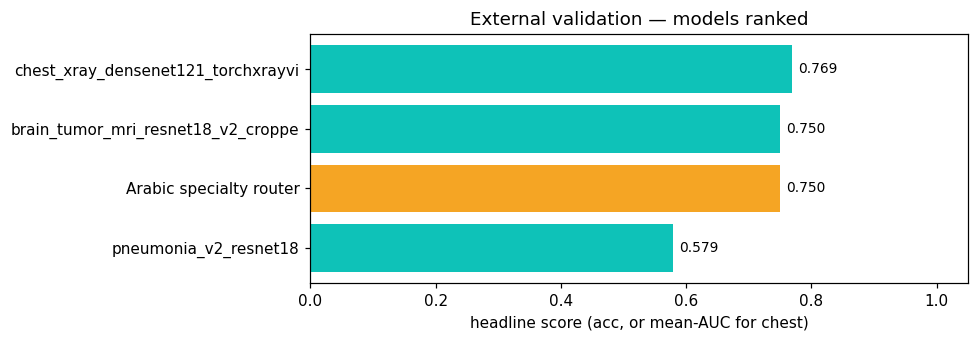

In [10]:
rows = []
for name in ["brain", "pneumonia", "chest", "text"]:
    p = os.path.join(RESULTS, f"{name}.json")
    if not os.path.exists(p): continue
    m = json.load(open(p, encoding="utf-8"))
    headline = (m.get("mean_auc") if name == "chest" else m.get("accuracy"))
    metric = "mean ROC-AUC" if name == "chest" else "accuracy"
    rows.append((m["model"].split("(")[0].strip()[:34], name, m["n_test"], metric, headline,
                 "external" if m.get("is_external_source") else "held-out"))
rows.sort(key=lambda r: (r[4] is not None, r[4]), reverse=True)

print(f"{'#':<2}{'model':36}{'n':>6}  {'metric':13}{'score':>7}  source")
print("-"*78)
for i,(mdl,nm,n,metric,score,src) in enumerate(rows,1):
    s = f"{score:.3f}" if score is not None else "  -  "
    print(f"{i:<2}{mdl:36}{n:>6}  {metric:13}{s:>7}  {src}")

names=[r[0] for r in rows][::-1]; scores=[r[4] or 0 for r in rows][::-1]
colors=["#0ec2b8" if r[5]=="external" else "#f5a524" for r in rows][::-1]
fig,ax=plt.subplots(figsize=(9,3.2))
ax.barh(names,scores,color=colors)
for i,s in enumerate(scores): ax.text(s+0.01,i,f"{s:.3f}",va="center",fontsize=9)
ax.set_xlim(0,1.05); ax.set_xlabel("headline score (acc, or mean-AUC for chest)")
ax.set_title("External validation — models ranked"); plt.tight_layout(); plt.show()